In [1]:
import pandas as pd
import matplotlib.pyplot as plt

How has daily Citi Bike ridership changed over time, and are there any noticeable trends, seasonal patterns, or gaps in the data?

In [2]:
df = pd.read_csv(
    "../data/daily_ridership_weather_clean.csv",
    parse_dates=["ride_date"]
)

In [3]:
df.head()

,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in
0,2013-07-01,16650,16.31,74.8,78.1,73.4,7.8,0.00
1,2013-07-02,22745,15.97,76.1,82.9,73.0,8.0,0.73
2,2013-07-03,21864,16.24,78.5,84.9,73.9,8.8,0.06
3,2013-07-04,22326,21.22,82.0,91.0,73.9,8.6,0.96
4,2013-07-05,21842,18.04,84.4,93.0,75.9,9.0,0.00


Is there a relationship between average daily temperature and the number of Citi Bike rides?

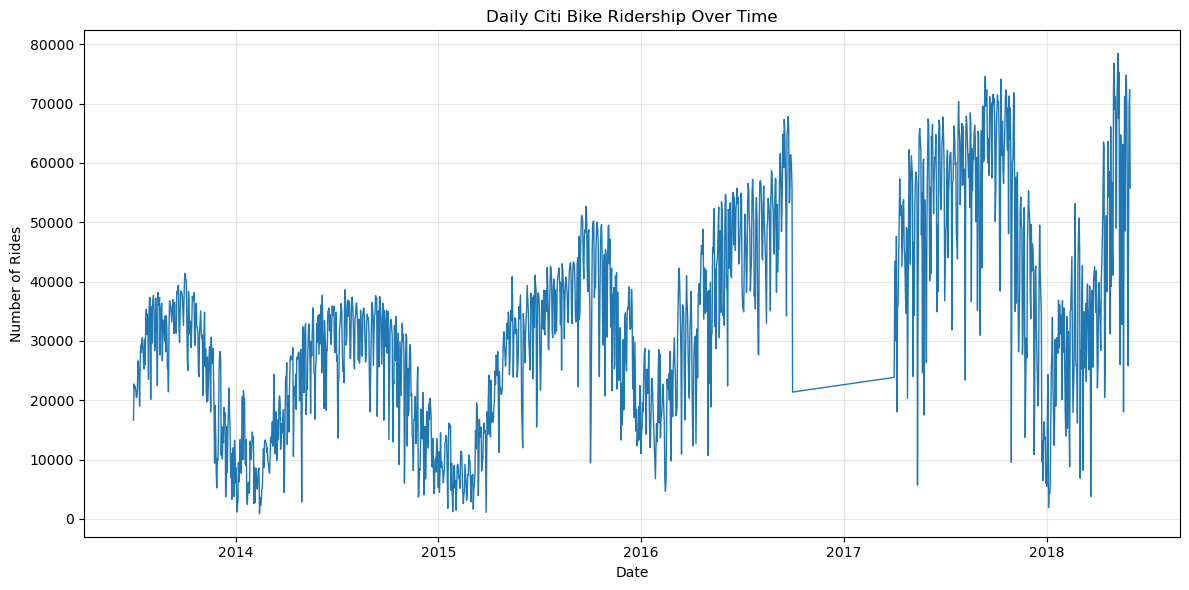

In [9]:
plt.figure(figsize=(12,6))

plt.plot(df["ride_date"], df["num_rides"], linewidth=1)

plt.title("Daily Citi Bike Ridership Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Rides")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Daily Citi Bike ridership generally increased from 2013 to 2018, with higher ridership during warmer months and lower ridership during colder months. A gap appears between October 2016 and March 2017 because no Citi Bike trip records are available for that period in the public BigQuery dataset.

Which weather variables have the strongest relationship with daily Citi Bike ridership?

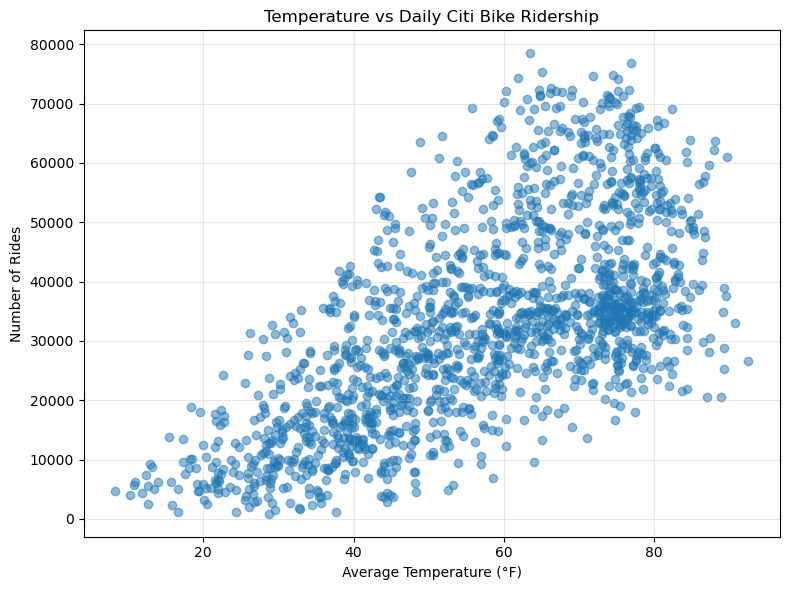

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(df["temp_f"], df["num_rides"], alpha=0.5)

plt.title("Temperature vs Daily Citi Bike Ridership")
plt.xlabel("Average Temperature (°F)")
plt.ylabel("Number of Rides")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The scatter plot shows a positive relationship between average temperature and daily Citi Bike ridership. Warmer days generally have more bike rides, while colder days tend to have fewer rides. However, the spread of points suggests that other variables besides temperature also influence daily ridership.

In [11]:
corr = df.select_dtypes(include="number").corr()

corr

,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in
num_rides,1.000000,0.329112,0.642993,0.643271,0.622907,-0.256536,-0.096539
avg_duration_min,0.329112,1.000000,0.373112,0.380154,0.351946,-0.147383,-0.013608
temp_f,0.642993,0.373112,1.000000,0.976912,0.978236,-0.360241,-0.023815
max_temp_f,0.643271,0.380154,0.976912,1.000000,0.952614,-0.328199,-0.017371
min_temp_f,0.622907,0.351946,0.978236,0.952614,1.000000,-0.325620,-0.017652
wind_speed_knots,-0.256536,-0.147383,-0.360241,-0.328199,-0.325620,1.000000,0.191246
precip_in,-0.096539,-0.013608,-0.023815,-0.017371,-0.017652,0.191246,1.000000


The correlation analysis shows that temperature has the strongest positive relationship with daily Citi Bike ridership (r ≈ 0.64). Wind speed has a weak negative relationship, while precipitation has only a very weak negative correlation. The three temperature variables are highly correlated with one another, indicating they measure similar weather conditions.

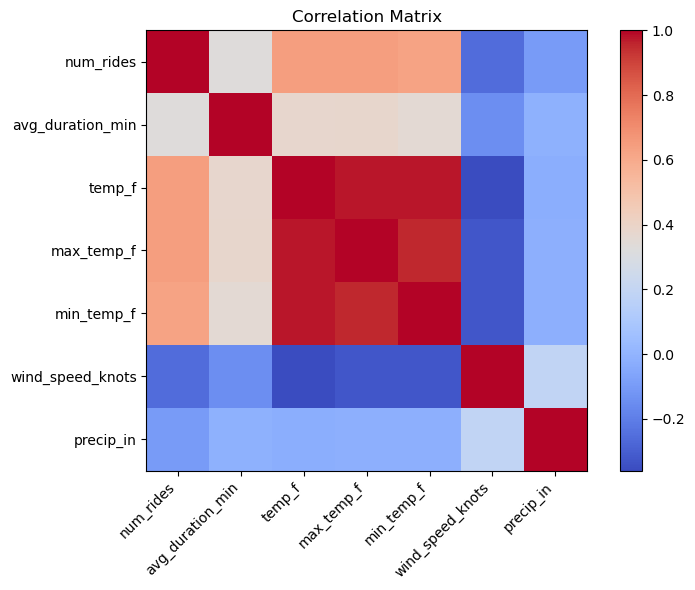

In [12]:
plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

The correlation matrix indicates that average, maximum, and minimum temperature have the strongest positive relationships with daily Citi Bike ridership (r ≈ 0.62–0.64). Wind speed shows a weak negative relationship with ridership, while precipitation has only a very weak negative correlation. The temperature variables are highly correlated with one another (r > 0.95), indicating they measure similar weather conditions.

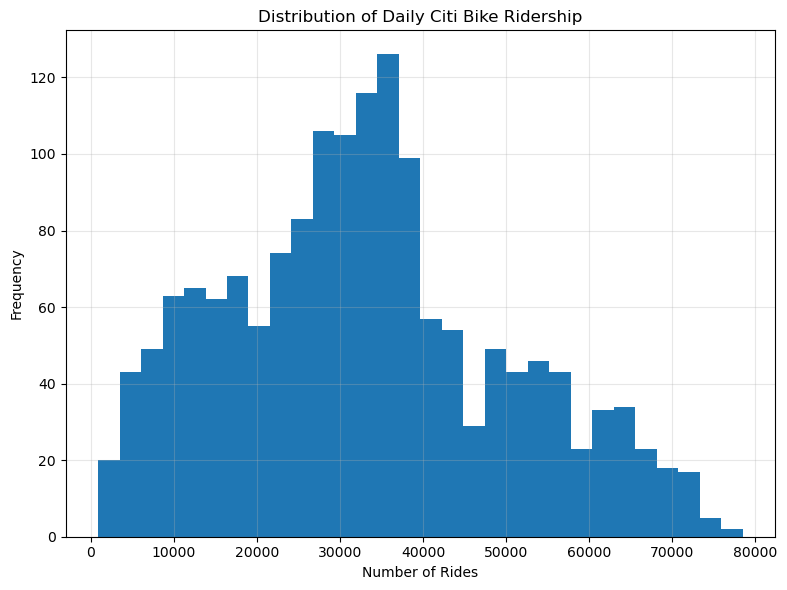

In [13]:
plt.figure(figsize=(8,6))

plt.hist(df["num_rides"], bins=30)

plt.title("Distribution of Daily Citi Bike Ridership")
plt.xlabel("Number of Rides")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The histogram shows that most days have between approximately 25,000 and 40,000 Citi Bike rides, with the highest concentration around 30,000–35,000 rides. The distribution is slightly right-skewed, indicating that while most days experience moderate ridership, a smaller number of days have exceptionally high ride counts.